# 🎯 Downstream Optimization Analysis
### GTM Intelligence Layer — From Raw Data to CSM-Ready Insights
---
> **Role Context:** This notebook is the analytical backbone for a Go-To-Market team.  
> It sits between raw SaaS behavioural data and Customer Success Managers, translating  
> product signals into revenue decisions — identifying who to retain, who to upsell, and  
> where to invest acquisition spend.

---

## 🗺️ Analytical Roadmap

| # | Analysis Module | Core SQL Pattern | Business Question | CSM Action |
|---|---|---|---|---|
| 1 | **MRR Waterfall & Revenue Momentum** | Window functions, LAG() | Where is MRR growing / leaking by tier? | Redirect retention resources |
| 2 | **Account Health Scoring Engine** | Multi-table JOIN, CASE scoring | Which accounts are at risk right now? | Prioritise outreach queue |
| 3 | **Churn Early Warning System** | CTEs, session decay signals | Who will churn in the next 30 days? | Trigger save playbooks |
| 4 | **Feature → Revenue Correlation** | Grouped aggregations, JOIN | What product behaviours drive expansion? | Build upsell narrative |
| 5 | **Upsell Intelligence Engine** | Business rules + scoring | Who is upgrade-ready today? | Generate upsell pipeline |
| 6 | **Acquisition Channel ROI** | Risk-adjusted LTV ranking | Which channels produce durable revenue? | Reallocate CAC budget |
| 7 | **Tableau Export Layer** | Final denormalized views | Package findings for CSM dashboards | Self-serve reporting |

---

**Stack:** Python · SQLite (SQL-on-CSV) · pandas · Matplotlib · Seaborn  
**Data:** 100K users · 1M billing records · 337K sessions · 234K events (18-month window)


## 📦 Setup & Data Ingestion

In [44]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

TIER_COLORS = {'free': '#8b949e', 'standard': '#58a6ff', 'enterprise': '#3fb950'}

DATA = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data')

if not os.path.exists("outputs"):
    os.mkdir("outputs")


In [45]:
# ── Load CSVs ─────────────────────────────────────────────────────────────
from os import mkdir


billing  = pd.read_csv(f'{DATA}/billing.csv')
users    = pd.read_csv(f'{DATA}/users.csv')
sessions = pd.read_csv(f'{DATA}/sessions.csv')
events   = pd.read_csv(f'{DATA}/events.csv')


# ── Load into in-memory SQLite ────────────────────────────────────────────
# DuckDB-compatible SQL (CTEs, window functions, CASE) runs on SQLite ≥ 3.25
conn = sqlite3.connect(':memory:')
billing.to_sql('billing',  conn, index=False, if_exists='replace')
users.to_sql('users',      conn, index=False, if_exists='replace')
sessions.to_sql('sessions',conn, index=False, if_exists='replace')
events.to_sql('events',    conn, index=False, if_exists='replace')

# ── Indexes for query performance ─────────────────────────────────────────
for ddl in [
    "CREATE INDEX idx_b_user  ON billing(user_id)",
    "CREATE INDEX idx_b_month ON billing(month)",
    "CREATE INDEX idx_s_user  ON sessions(user_id)",
    "CREATE INDEX idx_e_user  ON events(user_id)",
    "CREATE INDEX idx_e_feat  ON events(feature_name)",
]:
    conn.execute(ddl)
conn.commit()

def sql(query: str) -> pd.DataFrame:
    """Execute SQL and return a pandas DataFrame."""
    return pd.read_sql_query(query, conn)

print("✅  Database ready")
print(f"   billing : {len(billing):>10,} rows")
print(f"   users   : {len(users):>10,} rows")
print(f"   sessions: {len(sessions):>10,} rows")
print(f"   events  : {len(events):>10,} rows")
print(f"\n   SQLite version: {conn.execute('SELECT sqlite_version()').fetchone()[0]}")



✅  Database ready
   billing :  1,000,176 rows
   users   :    100,000 rows
   sessions:    336,717 rows
   events  :    234,329 rows

   SQLite version: 3.45.3


---
## 📊 Analysis 1 — MRR Waterfall & Revenue Momentum

**Business Question:** How is Monthly Recurring Revenue trending across plan tiers?  
Where is growth accelerating, and where is revenue leaking?


**CSM Impact:** Identifies which tiers are under-monetised and where to concentrate  
retention vs. expansion efforts to maximise MRR growth.


In [25]:
MRR_TREND_SQL = """
-- ── MRR Waterfall: Month-over-Month Revenue by Plan Tier ─────────────────
-- Window function LAG() computes prior-period MRR for delta calculation
WITH monthly_mrr AS (
    SELECT
        month,
        plan_tier,
        ROUND(SUM(mrr), 2)                                      AS total_mrr,
        COUNT(DISTINCT user_id)                                 AS paying_accounts,
        ROUND(AVG(mrr), 2)                                      AS arpu,
        ROUND(SUM(mrr)/ NULLIF(COUNT(DISTINCT user_id), 0), 2)  AS blended_arpu
    FROM billing
    GROUP BY month, plan_tier
),
mrr_with_lag AS (
    SELECT *,
        LAG(total_mrr) OVER (
            PARTITION BY plan_tier
            ORDER BY month
        ) AS prev_mrr
    FROM monthly_mrr
)
SELECT *,
    ROUND(total_mrr - COALESCE(prev_mrr, total_mrr), 2)  AS mrr_diff,
    CASE WHEN COALESCE(prev_mrr, 0) > 0
         THEN ROUND((total_mrr - prev_mrr) * 100.0 / prev_mrr, 2)
    END                                                    AS mrr_growth_pct
FROM mrr_with_lag
ORDER BY month, plan_tier
"""

mrr_trend = sql(MRR_TREND_SQL)
mrr_trend.to_csv("outputs/mrr_trend.csv", index=False)
mrr_trend.head(10)

,month,plan_tier,total_mrr,paying_accounts,arpu,blended_arpu,prev_mrr,mrr_diff,mrr_growth_pct
0,2024-02,free,0.0,3091,0.00,0.00,NaN,0.0,NaN
1,2024-02,premium,580395.0,894,649.21,649.21,NaN,0.0,NaN
2,2024-02,standard,527369.6,1679,314.10,314.10,NaN,0.0,NaN
3,2024-03,free,0.0,6326,0.00,0.00,0.0,0.0,NaN
4,2024-03,premium,1071201.0,1821,588.25,588.25,580395.0,490806.0,84.56
5,2024-03,standard,1100454.4,3435,320.37,320.37,527369.6,573084.8,108.67
6,2024-04,free,0.0,9591,0.00,0.00,0.0,0.0,NaN
7,2024-04,premium,1608564.0,2707,594.22,594.22,1071201.0,537363.0,50.16
8,2024-04,standard,1677416.0,5180,323.83,323.83,1100454.4,576961.6,52.43
9,2024-05,free,0.0,12918,0.00,0.00,0.0,0.0,NaN


Output is visualized with Tableau.

---
## 🏥 Analysis 2 — Account Health Scoring Engine

**Business Question:** Which accounts are at risk of churning, and which are thriving?

**SQL Patterns Used:** Multi-table `LEFT JOIN`, CASE-weighted scoring formula,  
`COALESCE` null-safety, `NULLIF` division guard, nested CTEs

**CSM Impact:** A single 0–100 composite score per account. CSMs see one number,  
not five spreadsheets. Threshold = 40 triggers automatic at-risk alert.

### Health Score Formula

| Dimension | Max Points | Signal |
|---|---|---|
| **Engagement Depth** — active months | 40 | Longitudinal stickiness |
| **Revenue Signal** — average MRR | 25 | Monetisation level |
| **Billing Health** — zero overdue invoices | 15 | Payment reliability |
| **Feature Exploration** — unique features used | 10 | Platform adoption |
| **Support Load** — low ticket count | 10 | Product satisfaction |



In [54]:
HEALTH_SCORE_SQL = """
-- ── Composite Account Health Score (0–100) ───────────────────────────────

WITH session_agg AS (
    SELECT
        user_id,
        COUNT(*)                                        AS session_count,
        ROUND(AVG(session_length_sec), 1)               AS avg_session_sec,
        COUNT(DISTINCT SUBSTR(session_start, 1, 7))     AS active_months
    FROM sessions
    GROUP BY user_id
),
event_agg AS (
    SELECT
        user_id,
        COUNT(DISTINCT feature_name)                    AS unique_features,
        COUNT(*)                                        AS total_events,
        ROUND(AVG(success) * 100, 1)                   AS event_success_rate,
        ROUND(AVG(latency_ms), 0)                      AS avg_latency_ms
    FROM events
    GROUP BY user_id
),
billing_agg AS (
    SELECT
        user_id,
        ROUND(AVG(mrr), 2)                             AS avg_mrr,
        ROUND(MAX(mrr), 2)                             AS peak_mrr,
        SUM(invoices_overdue)                          AS overdue_invoices,
        SUM(support_ticket_count)                      AS support_tickets,
        ROUND(AVG(active_seats), 1)                    AS avg_seats
    FROM billing
    GROUP BY user_id
)
SELECT
    u.user_id,
    u.plan_tier,
    u.company_size,
    u.industry,
    u.acquisition_channel,
    u.is_enterprise,
    u.churned_90d,
    u.expansion_event,
    COALESCE(s.session_count,   0)                     AS session_count,
    COALESCE(s.active_months,   0)                     AS active_months,
    COALESCE(e.unique_features, 0)                     AS unique_features,
    COALESCE(e.total_events,    0)                     AS total_events,
    COALESCE(e.event_success_rate, 0)                  AS event_success_rate,
    COALESCE(b.avg_mrr,         0)                     AS avg_mrr,
    COALESCE(b.peak_mrr,        0)                     AS peak_mrr,
    COALESCE(b.overdue_invoices,0)                     AS overdue_invoices,
    COALESCE(b.support_tickets, 0)                     AS support_tickets,
    COALESCE(b.avg_seats,       0)                     AS avg_seats,

    /* ── Composite Health Score ──────────────────────────────────── */
    MIN(100, 
        
        CASE WHEN COALESCE(s.active_months, 0) >= 10 THEN 40
             WHEN COALESCE(s.active_months, 0) >= 7 THEN 30
             WHEN COALESCE(s.active_months, 0) >= 4 THEN 20
             WHEN COALESCE(s.active_months, 0) >= 2 THEN  10
             ELSE 0 END
        
        + CASE WHEN COALESCE(b.avg_mrr, 0) >= 500 THEN 25
            WHEN COALESCE(b.avg_mrr, 0) >= 100 THEN 15
            WHEN COALESCE(b.avg_mrr, 0) > 0 THEN 5
            ELSE 0 END

        + CASE WHEN COALESCE(b.overdue_invoices, 0) = 0 THEN 15
            WHEN COALESCE(b.overdue_invoices, 0) <= 2 THEN 10
            ELSE 0 END
        
        + CASE WHEN COALESCE(e.unique_features, 0) >= 6 THEN 10
            WHEN COALESCE(e.unique_features, 0) >= 2 THEN 5
            ELSE 0 END

        + CASE WHEN COALESCE(b.support_tickets, 0) = 0 THEN 10
            WHEN COALESCE(b.support_tickets, 0) <= 2 THEN 5
            ELSE 0 END
    ) AS health_score

FROM users u
LEFT JOIN session_agg s ON u.user_id = s.user_id
LEFT JOIN event_agg   e ON u.user_id = e.user_id
LEFT JOIN billing_agg b ON u.user_id = b.user_id
"""

health = sql(HEALTH_SCORE_SQL)
health.to_sql('health_scores', conn, index=False, if_exists='replace')
health.to_csv("outputs/health_scores.csv", index=False)
print(f"Health scores computed for {len(health)} accounts")
health.head()


Health scores computed for 100000 accounts


,user_id,plan_tier,company_size,industry,acquisition_channel,is_enterprise,churned_90d,expansion_event,session_count,active_months,unique_features,total_events,event_success_rate,avg_mrr,peak_mrr,overdue_invoices,support_tickets,avg_seats,health_score
0,f94d1824-8742-4000-8b6d-39d70958490b,free,11-50,software,seo,0,0,1,0,0,0,0,0.0,0.00,0.0,0,0,1.5,25
1,238bf0af-1f71-45e4-a47d-dcb5db33f71b,standard,1-10,education,seo,0,0,0,0,0,0,0,0.0,8.00,8.0,0,0,1.0,30
2,ccf8fc06-3c86-433c-8867-9cba0fda337b,free,1-10,transport,partner,0,0,1,0,0,0,0,0.0,0.00,0.0,0,0,1.8,25
3,3e39c0ea-ebbf-43bc-abd5-ab92eff6fa10,standard,200+,software,partner,0,0,1,13,9,4,14,100.0,790.83,1024.0,0,30,101.5,75
4,9304dcbe-682d-41fa-8bfd-861559f9f58b,free,1-10,software,ads,0,1,1,1,1,0,0,0.0,0.00,0.0,1,0,1.5,20


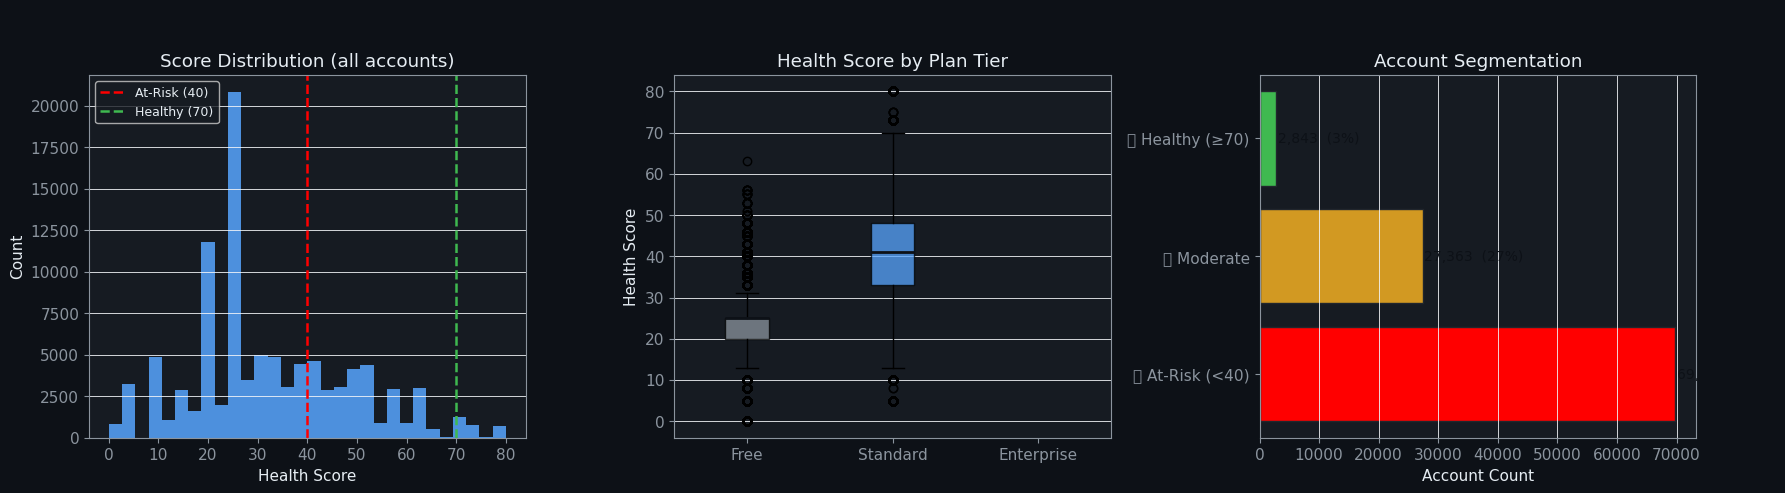


💡 KEY INSIGHT — Revenue at Risk
─────────────────────────────────────────────
  At-risk accounts (score < 40) : 69,794  (69.8% of base)
  Total MRR at risk             : $1,898,756 / month
  Annualised revenue at risk    : $22,785,073

  → Proactive CSM outreach targeting these 69,794 accounts
    could protect $22,785,073 ARR — before churn occurs.


In [41]:
# ── Health Score Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Account Health Score Distribution', fontsize=15, fontweight='bold', color=TEXT)

# Distribution histogram
axes[0].hist(health['health_score'], bins=30, color=ACCENT, alpha=0.85)
for threshold, label, color in [(40, 'At-Risk', '#ff0000'), (70, 'Healthy', GREEN)]:
    axes[0].axvline(threshold, color=color, linewidth=1.8, linestyle='--', label=f'{label} ({threshold})')
axes[0].set(title='Score Distribution (all accounts)', xlabel='Health Score', ylabel='Count')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y')

# Box plot by plan tier
plan_order = ['free', 'standard', 'enterprise']
plan_data  = [health.loc[health['plan_tier']==t, 'health_score'].values for t in plan_order]
bp = axes[1].boxplot(plan_data, labels=[t.title() for t in plan_order],
                     patch_artist=True, medianprops={'color': TEXT, 'linewidth': 2})
for patch, tier in zip(bp['boxes'], plan_order):
    patch.set_facecolor(TIER_COLORS.get(tier, ACCENT))
    patch.set_alpha(0.75)
axes[1].set(title='Health Score by Plan Tier', ylabel='Health Score')
axes[1].grid(True, axis='y')

# At-risk vs healthy count
seg = health.assign(
    segment=lambda d: d['health_score'].apply(
        lambda s: '🔴 At-Risk (<40)' if s < 40 else ('🟢 Healthy (≥70)' if s >= 70 else '🟡 Moderate'))
)['segment'].value_counts()
colors_seg = {'🔴 At-Risk (<40)': '#ff0000', '🟡 Moderate': '#d29922', '🟢 Healthy (≥70)': '#3fb950'}
axes[2].barh(seg.index, seg.values,
             color=[colors_seg[s] for s in seg.index], edgecolor='#21262d')
for i, (idx, val) in enumerate(seg.items()):
    axes[2].text(val + 200, i, f'{val:,}  ({val/len(health)*100:.0f}%)',
                 va='center', fontsize=10, color=TEXT)
axes[2].set(title='Account Segmentation', xlabel='Account Count')
axes[2].grid(True, axis='x')

plt.tight_layout()
plt.savefig('outputs/02_health_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Revenue at Risk ──────────────────────────────────────────────────────
at_risk = health[health['health_score'] < 40]
risk_mrr = at_risk['avg_mrr'].sum()
print(f"\n💡 KEY INSIGHT — Revenue at Risk")
print("─" * 45)
print(f"  At-risk accounts (score < 40) : {len(at_risk):,}  ({len(at_risk)/len(health)*100:.1f}% of base)")
print(f"  Total MRR at risk             : ${risk_mrr:,.0f} / month")
print(f"  Annualised revenue at risk    : ${risk_mrr*12:,.0f}")
print(f"\n  → Proactive CSM outreach targeting these {len(at_risk):,} accounts")
print(f"    could protect ${risk_mrr*12:,.0f} ARR — before churn occurs.")


---
## ⚠️ Analysis 3 — Churn Early Warning System

**Business Question:** Which currently-active accounts show engagement decay signals  
that historically precede churn? Surface them to CSMs 30–60 days before it happens.

**SQL Patterns Used:** CTEs with `SUBSTR` date slicing, self-referencing subqueries  
replaced by ranked window functions (`ROW_NUMBER`, `DENSE_RANK`), conditional aggregation

**Revenue Impact:** Every $1 spent on proactive retention is worth $5 in avoided  
re-acquisition cost (industry benchmark). Early warning = cheapest retention tool.

### Decay Signals Monitored
| Signal | Definition | Risk Implication |
|---|---|---|
| 🔴 **Gone Dark** | Zero sessions in latest active month | Immediate churn risk |
| 🟠 **Rapid Decline** | Sessions dropped >50% month-over-month | High churn risk |
| 🟡 **Mild Decline** | Sessions dropped 25–50% MoM | Elevated risk — monitor |
| 🟢 **Stable** | Consistent or growing session activity | Low immediate risk |


In [56]:
CHURN_WARNING_SQL = """
-- ── Engagement Decay Churn Early Warning ─────────────────────────────────
-- Uses ROW_NUMBER to rank months per user, avoiding slow correlated subqueries
WITH user_monthly AS (
    SELECT
        user_id,
        SUBSTR(session_start, 1, 7)          AS month,
        COUNT(*)                             AS monthly_sessions
    FROM sessions
    GROUP BY user_id, SUBSTR(session_start, 1, 7)
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY month DESC
        ) AS month_rank
    FROM user_monthly
),
current_vs_prior AS (
    SELECT
        user_id,
        MAX(CASE WHEN month_rank = 1 THEN month            END) AS latest_month,
        MAX(CASE WHEN month_rank = 1 THEN monthly_sessions END) AS latest_sessions,
        MAX(CASE WHEN month_rank = 2 THEN monthly_sessions END) AS prev_sessions
    FROM ranked
    WHERE month_rank <= 2
    GROUP BY user_id
),
billing_agg AS (
    SELECT user_id,
           ROUND(AVG(mrr), 2) AS avg_mrr,
           SUM(support_ticket_count) AS total_tickets
    FROM billing
    GROUP BY user_id
)
SELECT
    c.user_id,
    u.plan_tier,
    u.industry,
    u.company_size,
    u.region,
    b.avg_mrr,
    b.total_tickets,
    c.latest_month,
    COALESCE(c.latest_sessions, 0)  AS latest_sessions,
    COALESCE(c.prev_sessions,   0)  AS prev_sessions,

    ROUND(
        CASE
            WHEN COALESCE(c.prev_sessions, 0) > 0
            THEN (COALESCE(c.latest_sessions,0) - c.prev_sessions) * 100.0 / c.prev_sessions
            ELSE 0
        END, 1
    )                               AS session_delta_pct,

    CASE
        WHEN COALESCE(c.latest_sessions, 0) = 0
             THEN 'Gone Dark'
        WHEN COALESCE(c.latest_sessions, 0) < COALESCE(c.prev_sessions, 0) * 0.50
             THEN 'Rapid Decline'
        WHEN COALESCE(c.latest_sessions, 0) < COALESCE(c.prev_sessions, 0) * 0.75
             THEN 'Mild Decline'
        ELSE 'Stable'
    END                             AS engagement_signal,

    CASE
        WHEN COALESCE(c.latest_sessions, 0) = 0
             THEN 1
        WHEN COALESCE(c.latest_sessions, 0) < COALESCE(c.prev_sessions, 0) * 0.50
             THEN 2
        WHEN COALESCE(c.latest_sessions, 0) < COALESCE(c.prev_sessions, 0) * 0.75
             THEN 3
        ELSE 4
    END                             AS risk_priority

FROM current_vs_prior c
JOIN users u ON c.user_id = u.user_id
LEFT JOIN billing_agg b ON c.user_id = b.user_id
WHERE u.churned_90d = 0   -- only flag currently-active accounts
ORDER BY risk_priority, avg_mrr DESC
"""

churn_warning = sql(CHURN_WARNING_SQL)
print(f"Early warning system: {len(churn_warning):,} active accounts monitored")

signal_summary = churn_warning.groupby('engagement_signal').agg(
    account_count=('user_id', 'count'),
    total_mrr_at_risk=('avg_mrr', 'sum'),
    avg_mrr=('avg_mrr', 'mean')
).round(2).sort_values('account_count', ascending=False)
print("\n", signal_summary.to_string())


Early warning system: 58,573 active accounts monitored

                    account_count  total_mrr_at_risk  avg_mrr
engagement_signal                                           
Stable                     50897        12773101.10   250.96
Mild Decline                6149         2914217.63   473.93
Rapid Decline               1527          969219.64   634.72


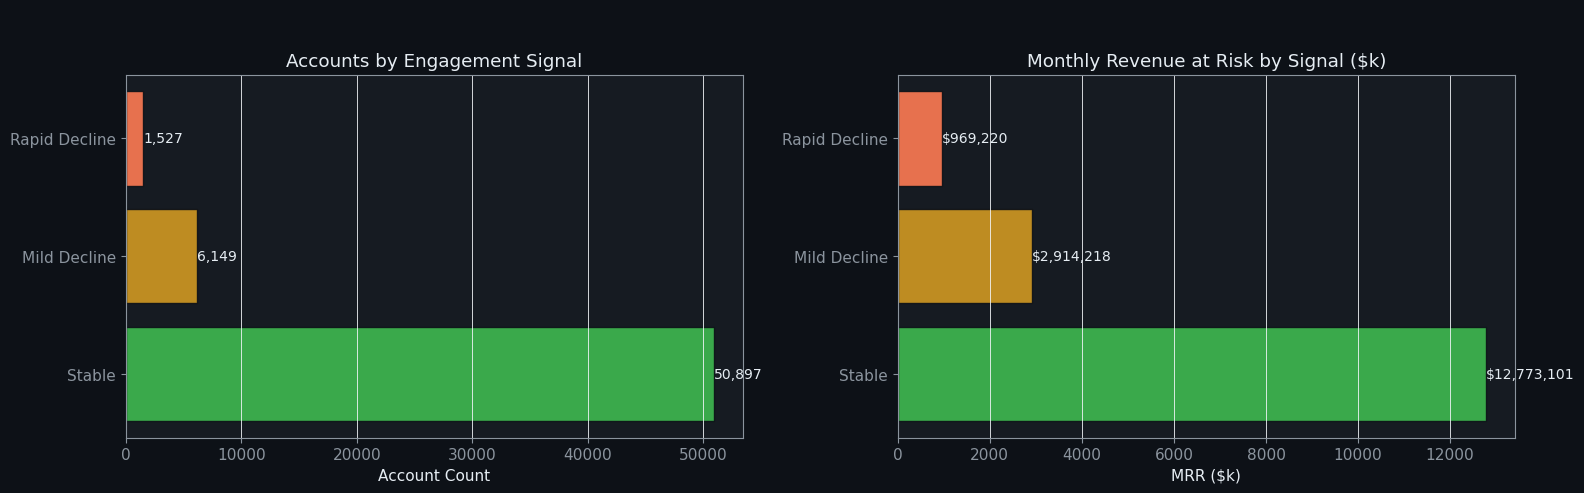


💡 KEY INSIGHT — Immediate CSM Action Required
──────────────────────────────────────────────────
  Gone Dark accounts    : 0  → $0/mo at risk
  Rapid Decline accounts: 1,527  → $969,220/mo at risk
  Combined rescue ARR   : $11,630,636

  CSM Playbook: Trigger personalised re-engagement within 7 days for Gone Dark accounts.
  Even 20% save rate = $2,326,127 ARR preserved.


In [57]:
# ── Churn Risk Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Churn Early Warning — Engagement Decay Signals', fontsize=15, fontweight='bold', color=TEXT)

SIGNAL_COLORS = {
    'Gone Dark':     RED,
    'Rapid Decline': '#ff7b54',
    'Mild Decline':  YELLOW,
    'Stable':        GREEN
}

sig_grp = churn_warning.groupby('engagement_signal').agg(
    accounts=('user_id','count'), mrr_at_risk=('avg_mrr','sum')
).reset_index().sort_values('mrr_at_risk', ascending=False)

bars = axes[0].barh(sig_grp['engagement_signal'], sig_grp['accounts'],
                    color=[SIGNAL_COLORS[s] for s in sig_grp['engagement_signal']],
                    edgecolor=DARK_BG, alpha=0.9)
for bar, val in zip(bars, sig_grp['accounts']):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)
axes[0].set(title='Accounts by Engagement Signal', xlabel='Account Count')
axes[0].grid(True, axis='x')

# MRR at risk by signal
bars2 = axes[1].barh(sig_grp['engagement_signal'], sig_grp['mrr_at_risk']/1000,
                     color=[SIGNAL_COLORS[s] for s in sig_grp['engagement_signal']],
                     edgecolor=DARK_BG, alpha=0.9)
for bar, val in zip(bars2, sig_grp['mrr_at_risk']):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=10)
axes[1].set(title='Monthly Revenue at Risk by Signal ($k)', xlabel='MRR ($k)')
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.savefig('outputs/03_churn_warning.png', dpi=150, bbox_inches='tight')
plt.show()

gone_dark = churn_warning[churn_warning['engagement_signal']=='Gone Dark']
rapid     = churn_warning[churn_warning['engagement_signal']=='Rapid Decline']
print(f"\n💡 KEY INSIGHT — Immediate CSM Action Required")
print("─" * 50)
print(f"  Gone Dark accounts    : {len(gone_dark):,}  → ${gone_dark['avg_mrr'].sum():,.0f}/mo at risk")
print(f"  Rapid Decline accounts: {len(rapid):,}  → ${rapid['avg_mrr'].sum():,.0f}/mo at risk")
print(f"  Combined rescue ARR   : ${(gone_dark['avg_mrr'].sum() + rapid['avg_mrr'].sum())*12:,.0f}")
print(f"\n  CSM Playbook: Trigger personalised re-engagement within 7 days for Gone Dark accounts.")
print(f"  Even 20% save rate = ${(gone_dark['avg_mrr'].sum() + rapid['avg_mrr'].sum())*12*0.20:,.0f} ARR preserved.")


---
## 🎯 Analysis 4 — Feature → Revenue Correlation

**Business Question:** Which product features correlate most strongly with  
expansion revenue — and which correlate with churn? This directly informs  
the CSM upsell narrative: "customers who use X are 2× more likely to expand."

**SQL Patterns Used:** Two-level aggregation (user-level then feature-level),  
`HAVING` filter, derived metrics, sorted output for ranking

**CSM Impact:** Gives CSMs a data-backed story to use in QBRs:  
*"Clients using Jira Automation have 52% lower churn than those who don't."*


In [60]:
FEATURE_REVENUE_SQL = """
-- ── Feature → Expansion Correlation ─────────────────────────────────────
-- First aggregates at user × feature level, then rolls up to feature level
-- to compute expansion rate, churn rate, and a net value score
WITH feature_per_user AS (
    SELECT
        e.feature_name,
        e.user_id,
        COUNT(*)                        AS event_count,
        ROUND(AVG(e.success) * 100, 1)  AS success_rate,
        ROUND(AVG(e.latency_ms), 0)     AS avg_latency_ms,
        ROUND(AVG(e.duration_ms), 0)    AS avg_duration_ms
    FROM events e
    GROUP BY e.feature_name, e.user_id
)
SELECT
    f.feature_name,
    COUNT(DISTINCT f.user_id)                           AS users_using_feature,
    ROUND(AVG(u.expansion_event) * 100, 1)              AS expansion_rate_pct,
    ROUND(AVG(u.churned_90d)     * 100, 1)              AS churn_rate_pct,
    ROUND(AVG(f.success_rate), 1)                       AS avg_success_rate,
    ROUND(AVG(f.avg_latency_ms), 0)                     AS avg_latency_ms,
    ROUND(AVG(f.avg_duration_ms), 0)                    AS avg_duration_ms,
    ROUND(AVG(f.event_count), 1)                        AS avg_events_per_user,

    /* Net Value Score: expansion lift minus churn drag */
    ROUND(AVG(u.expansion_event)*100 - AVG(u.churned_90d)*100, 1)
                                                        AS net_value_score,

    /* Adoption score: users * success rate proxy */
    ROUND(COUNT(DISTINCT f.user_id) * AVG(f.success_rate) / 100, 0)
                                                        AS effective_adoption

FROM feature_per_user f
JOIN users u ON f.user_id = u.user_id
GROUP BY f.feature_name
HAVING COUNT(DISTINCT f.user_id) >= 50
ORDER BY net_value_score DESC
"""

feature_rev = sql(FEATURE_REVENUE_SQL)
feature_rev


,feature_name,users_using_feature,expansion_rate_pct,churn_rate_pct,avg_success_rate,avg_latency_ms,avg_duration_ms,avg_events_per_user,net_value_score,effective_adoption
0,team_invite,13911,65.1,10.6,90.0,259.0,1207.0,1.3,54.4,12522.0
1,bitbucket_integration,13086,65.2,12.1,79.5,261.0,1205.0,1.5,53.1,10406.0
2,jira_automation,22494,65.6,13.0,90.1,259.0,1198.0,2.0,52.6,20263.0
3,trello_export_csv,7549,64.5,12.1,90.2,263.0,1186.0,1.5,52.4,6810.0
4,confluence_ai_assist,12153,65.6,13.2,89.6,260.0,1189.0,2.0,52.4,10890.0
5,jira_board,31734,66.1,14.8,96.9,261.0,844.0,2.5,51.4,30765.0
6,confluence_page,16457,65.7,15.0,97.1,261.0,844.0,2.4,50.7,15977.0


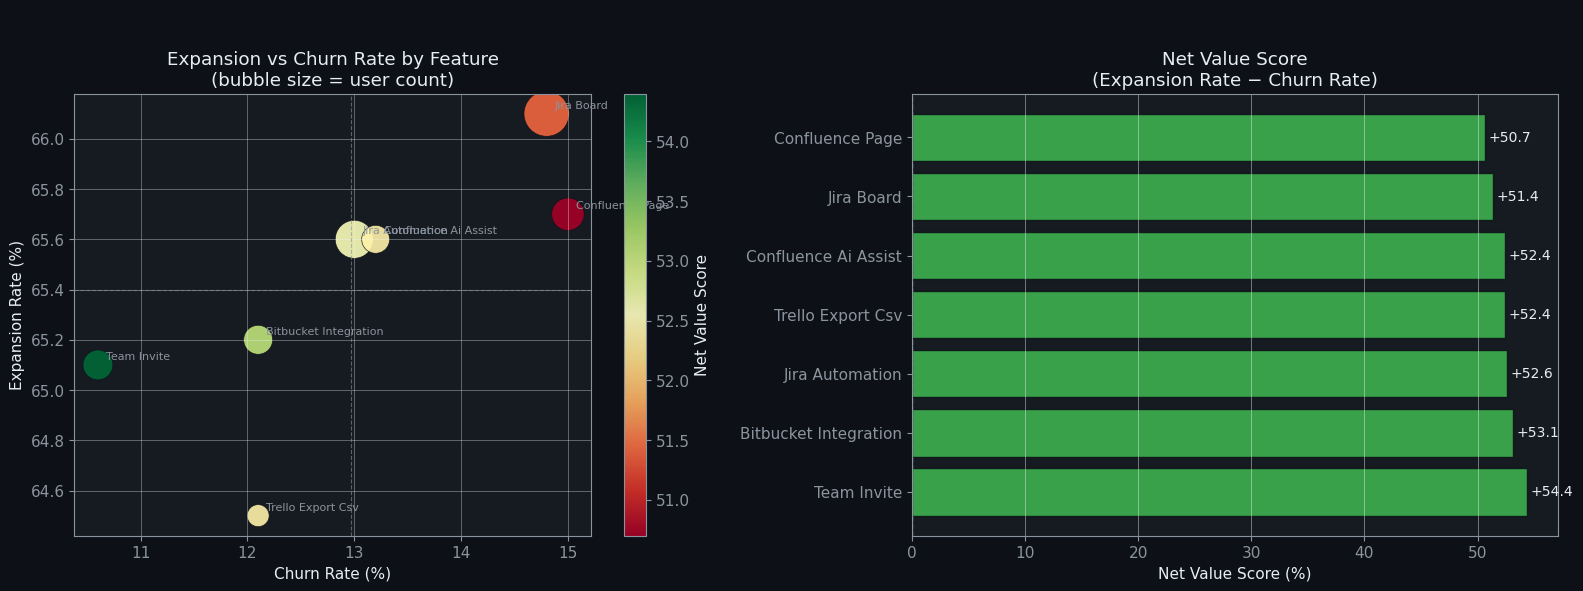


💡 KEY INSIGHT — Upsell Narrative for CSMs
───────────────────────────────────────────────────────
  Top feature: team_invite
  Users who engage with it have:
    • Expansion rate : 65.1%  (vs 65.4% avg)
    • Churn rate     : 10.6%  (vs 13.0% avg)
    • Net Value Score: +54.4

  → QBR Talking Point: 'Clients actively using Team Invite
    are 1.0× more likely to expand their contract.'


In [61]:
# ── Feature Correlation Matrix ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature → Revenue Correlation Analysis', fontsize=15, fontweight='bold', color=TEXT)

# Scatter: Expansion Rate vs Churn Rate
scatter = axes[0].scatter(
    feature_rev['churn_rate_pct'],
    feature_rev['expansion_rate_pct'],
    s=feature_rev['users_using_feature'] / 30,
    c=feature_rev['net_value_score'],
    cmap='RdYlGn',
    alpha=0.9,
    edgecolors=DARK_BG,
    linewidths=0.5
)
for _, row in feature_rev.iterrows():
    axes[0].annotate(
        row['feature_name'].replace('_', ' ').title(),
        (row['churn_rate_pct'], row['expansion_rate_pct']),
        textcoords='offset points', xytext=(6, 4), fontsize=8, color=MUTED
    )
plt.colorbar(scatter, ax=axes[0], label='Net Value Score')
avg_churn = feature_rev['churn_rate_pct'].mean()
avg_exp   = feature_rev['expansion_rate_pct'].mean()
axes[0].axvline(avg_churn, color=MUTED, linewidth=0.8, linestyle='--', alpha=0.6)
axes[0].axhline(avg_exp,   color=MUTED, linewidth=0.8, linestyle='--', alpha=0.6)
axes[0].set(title='Expansion vs Churn Rate by Feature\n(bubble size = user count)',
            xlabel='Churn Rate (%)', ylabel='Expansion Rate (%)')
axes[0].grid(True, alpha=0.4)

# Bar: Net Value Score
colors_nv = [GREEN if v >= 0 else RED for v in feature_rev['net_value_score']]
bars = axes[1].barh(feature_rev['feature_name'].str.replace('_',' ').str.title(),
                    feature_rev['net_value_score'],
                    color=colors_nv, edgecolor=DARK_BG, alpha=0.85)
for bar, val in zip(bars, feature_rev['net_value_score']):
    x = bar.get_width() + 0.3 if val >= 0 else bar.get_width() - 2
    axes[1].text(x, bar.get_y() + bar.get_height()/2,
                 f'{val:+.1f}', va='center', fontsize=10)
axes[1].set(title='Net Value Score\n(Expansion Rate − Churn Rate)',
            xlabel='Net Value Score (%)')
axes[1].axvline(0, color=MUTED, linewidth=1, linestyle='--')
axes[1].grid(True, axis='x', alpha=0.5)

plt.tight_layout()
plt.savefig('outputs/04_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

top_feature = feature_rev.iloc[0]
print(f"\n💡 KEY INSIGHT — Upsell Narrative for CSMs")
print("─" * 55)
print(f"  Top feature: {top_feature['feature_name']}")
print(f"  Users who engage with it have:")
print(f"    • Expansion rate : {top_feature['expansion_rate_pct']}%  (vs {feature_rev['expansion_rate_pct'].mean():.1f}% avg)")
print(f"    • Churn rate     : {top_feature['churn_rate_pct']}%  (vs {feature_rev['churn_rate_pct'].mean():.1f}% avg)")
print(f"    • Net Value Score: {top_feature['net_value_score']:+.1f}")
print(f"\n  → QBR Talking Point: 'Clients actively using {top_feature['feature_name'].replace('_',' ').title()}")
print(f"    are {top_feature['expansion_rate_pct']/feature_rev['expansion_rate_pct'].mean():.1f}× more likely to expand their contract.'")


---
## 💰 Analysis 5 — Upsell Intelligence Engine

**Business Question:** Which accounts are ready to upgrade *right now*,  
and what is the total addressable expansion revenue if we act on these leads?

**SQL Patterns Used:** Multi-CTE scoring pipeline, business-rule `CASE` logic,  
`NULLIF` guard, summary aggregation with `GROUP BY` rollup

**Commercial Impact:** This is the "expansion pipeline" view — the revenue a  
sales team can capture without spending on new customer acquisition.  
A well-executed upsell motion can add 20–40% ARR on existing customers alone.

### Upsell Tier Definitions
| Signal | Criteria | CSM Action |
|---|---|---|
| 🔥 **HOT — Free→Standard** | Free plan + ≥4 active months + ≥3 features + no overdue invoices | Immediate direct outreach |
| 🔥 **HOT — Standard→Enterprise** | Standard + ≥25 seats + ≥8 active months + no overdue invoices | AE-led conversation |
| 🌡️ **WARM — Nurture to Standard** | Free plan + ≥2 active months + ≥2 features | Automated nurture sequence |
| 📈 **WARM — Expand Seat Count** | Standard + ≥15 avg seats | Seat expansion campaign |


In [62]:
UPSELL_INTEL_SQL = """
-- ── Upsell Intelligence: Opportunity Sizing ──────────────────────────────
-- Pipeline: billing_agg → session_agg → event_agg → scoring → rollup
WITH billing_agg AS (
    SELECT
        user_id,
        ROUND(AVG(mrr), 2)             AS avg_mrr,
        ROUND(MAX(mrr), 2)             AS peak_mrr,
        SUM(invoices_overdue)          AS overdue_invoices,
        SUM(support_ticket_count)      AS support_tickets,
        ROUND(AVG(active_seats), 1)    AS avg_seats,
        COUNT(DISTINCT month)          AS billing_months
    FROM billing
    GROUP BY user_id
),
session_agg AS (
    SELECT
        user_id,
        COUNT(*)                                    AS session_count,
        COUNT(DISTINCT SUBSTR(session_start,1,7))   AS active_months
    FROM sessions
    GROUP BY user_id
),
event_agg AS (
    SELECT user_id,
           COUNT(DISTINCT feature_name)             AS unique_features
    FROM events
    GROUP BY user_id
),
scored AS (
    SELECT
        u.user_id,
        u.plan_tier,
        u.company_size,
        u.region,
        u.industry,
        COALESCE(b.avg_mrr,          0) AS avg_mrr,
        COALESCE(b.avg_seats,        0) AS avg_seats,
        COALESCE(b.overdue_invoices, 0) AS overdue_invoices,
        COALESCE(b.support_tickets,  0) AS support_tickets,
        COALESCE(s.session_count,    0) AS session_count,
        COALESCE(s.active_months,    0) AS active_months,
        COALESCE(e.unique_features,  0) AS unique_features,
        u.churned_90d,
        u.expansion_event,

        /* ── Upsell Action Tag ──────────────────────────────── */
        CASE
            WHEN u.plan_tier = 'free'
                 AND COALESCE(s.active_months,    0) >= 4
                 AND COALESCE(e.unique_features,  0) >= 3
                 AND COALESCE(b.overdue_invoices, 0) =  0
                 THEN 'HOT — Free to Standard'
            WHEN u.plan_tier = 'standard'
                 AND COALESCE(b.avg_seats,        0) >= 25
                 AND COALESCE(s.active_months,    0) >= 8
                 AND COALESCE(b.overdue_invoices, 0) =  0
                 THEN 'HOT — Standard to Enterprise'
            WHEN u.plan_tier = 'free'
                 AND COALESCE(s.active_months,    0) >= 2
                 AND COALESCE(e.unique_features,  0) >= 2
                 THEN 'WARM — Nurture to Standard'
            WHEN u.plan_tier = 'standard'
                 AND COALESCE(b.avg_seats,        0) >= 15
                 THEN 'WARM — Expand Seat Count'
            ELSE 'MONITOR'
        END AS csm_action,

        /* ── Monthly Revenue Upside ─────────────────────────── */
        CASE
            WHEN u.plan_tier = 'free'     THEN 108
            WHEN u.plan_tier = 'standard'
                 AND COALESCE(b.avg_seats,0) >= 25 THEN 900
            WHEN u.plan_tier = 'standard' THEN 200
            ELSE 0
        END AS monthly_revenue_upside

    FROM users u
    LEFT JOIN billing_agg b ON u.user_id = b.user_id
    LEFT JOIN session_agg s ON u.user_id = s.user_id
    LEFT JOIN event_agg   e ON u.user_id = e.user_id
    WHERE u.churned_90d = 0
)
SELECT
    csm_action,
    COUNT(*)                                AS account_count,
    ROUND(AVG(avg_mrr), 2)                  AS avg_current_mrr,
    SUM(monthly_revenue_upside)             AS total_monthly_upside,
    ROUND(SUM(monthly_revenue_upside)*12,0) AS annualised_pipeline,
    ROUND(AVG(active_months), 1)            AS avg_active_months,
    ROUND(AVG(unique_features), 1)          AS avg_features_used,
    ROUND(AVG(avg_seats), 1)                AS avg_seats
FROM scored
WHERE csm_action != 'MONITOR'
GROUP BY csm_action
ORDER BY total_monthly_upside DESC
"""

upsell = sql(UPSELL_INTEL_SQL)
total_pipeline = upsell['annualised_pipeline'].sum()
print(f"💰 Total Addressable Expansion Pipeline: ${total_pipeline:,.0f} ARR")
print()
upsell


💰 Total Addressable Expansion Pipeline: $103,238,736 ARR



,csm_action,account_count,avg_current_mrr,total_monthly_upside,annualised_pipeline,avg_active_months,avg_features_used,avg_seats
0,WARM — Expand Seat Count,11582,577.91,7329800,87957600.0,3.8,1.9,75.2
1,HOT — Standard to Enterprise,945,1112.89,850500,10206000.0,9.2,3.1,144.8
2,WARM — Nurture to Standard,3657,5.71,394956,4739472.0,2.8,2.2,21.9
3,HOT — Free to Standard,259,9.22,27972,335664.0,4.8,3.2,27.6


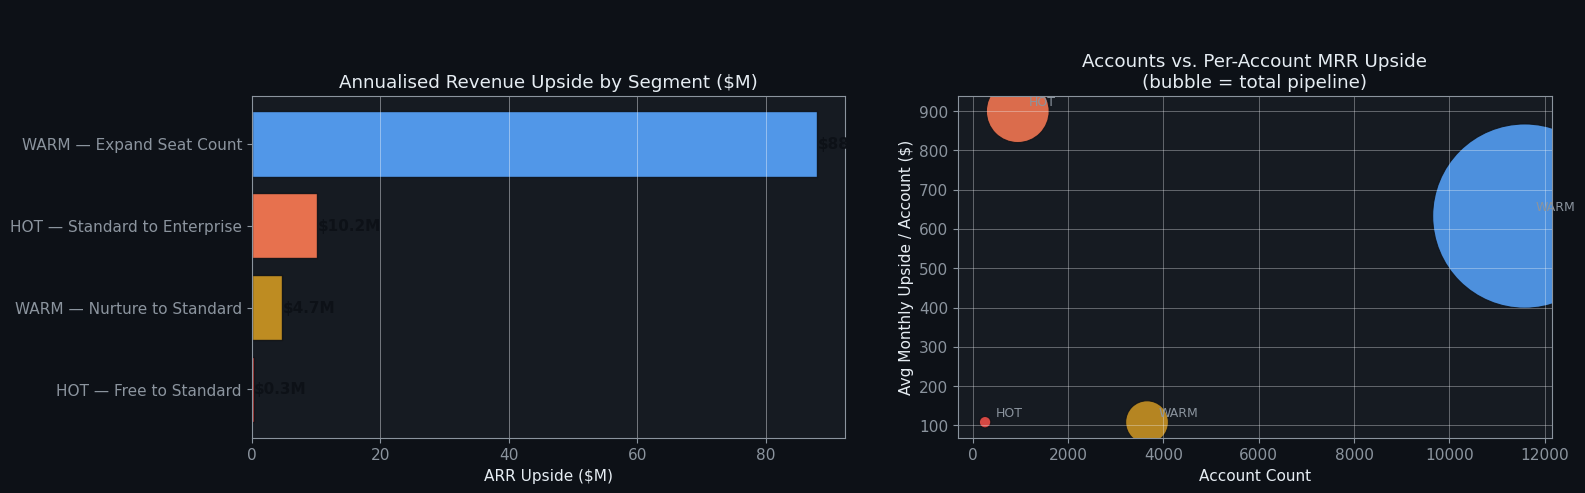


💡 KEY INSIGHT — Expansion Pipeline Summary
───────────────────────────────────────────────────────
  Total addressable expansion ARR : $   103,238,736
  HOT leads (immediate outreach)  :   1,204 accounts  → $  10,541,664 ARR
  WARM leads (nurture sequence)   :  15,239 accounts  → $  92,697,072 ARR

  → HOT leads require direct CSM contact within 5 business days.
    Use Feature Correlation data (Analysis 4) to personalise the pitch.


In [63]:
# ── Upsell Pipeline Visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Upsell Intelligence — Expansion Revenue Pipeline', fontsize=15, fontweight='bold', color=TEXT)

ACTION_COLORS = {
    'HOT — Free to Standard':         RED,
    'HOT — Standard to Enterprise':   '#ff7b54',
    'WARM — Nurture to Standard':     YELLOW,
    'WARM — Expand Seat Count':       ACCENT,
}

# Annualised pipeline by segment
upsell_plot = upsell[upsell['csm_action'] != 'MONITOR'].sort_values('annualised_pipeline', ascending=True)
bars = axes[0].barh(
    upsell_plot['csm_action'],
    upsell_plot['annualised_pipeline'] / 1_000_000,
    color=[ACTION_COLORS.get(a, ACCENT) for a in upsell_plot['csm_action']],
    edgecolor=DARK_BG, alpha=0.9
)
for bar, val in zip(bars, upsell_plot['annualised_pipeline']):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:.1f}M', va='center', fontsize=11, fontweight='bold', color=TEXT)
axes[0].set(title='Annualised Revenue Upside by Segment ($M)', xlabel='ARR Upside ($M)')
axes[0].grid(True, axis='x', alpha=0.5)

# Account count vs avg upside
axes[1].scatter(
    upsell_plot['account_count'],
    upsell_plot['total_monthly_upside'] / upsell_plot['account_count'],
    s=upsell_plot['annualised_pipeline'] / 5000,
    c=[ACTION_COLORS.get(a, ACCENT) for a in upsell_plot['csm_action']],
    alpha=0.85, edgecolors=DARK_BG, linewidths=0.8
)
for _, row in upsell_plot.iterrows():
    axes[1].annotate(
        row['csm_action'].split('—')[0].strip(),
        (row['account_count'], row['total_monthly_upside']/row['account_count']),
        textcoords='offset points', xytext=(8, 4), fontsize=9, color=MUTED
    )
axes[1].set(title='Accounts vs. Per-Account MRR Upside\n(bubble = total pipeline)',
            xlabel='Account Count', ylabel='Avg Monthly Upside / Account ($)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('outputs/05_upsell_intelligence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 KEY INSIGHT — Expansion Pipeline Summary")
print("─" * 55)
print(f"  Total addressable expansion ARR : ${upsell['annualised_pipeline'].sum():>14,.0f}")
hot = upsell[upsell['csm_action'].str.startswith('HOT')]
warm = upsell[upsell['csm_action'].str.startswith('WARM')]
print(f"  HOT leads (immediate outreach)  : {hot['account_count'].sum():>7,} accounts  → ${hot['annualised_pipeline'].sum():>12,.0f} ARR")
print(f"  WARM leads (nurture sequence)   : {warm['account_count'].sum():>7,} accounts  → ${warm['annualised_pipeline'].sum():>12,.0f} ARR")
print(f"\n  → HOT leads require direct CSM contact within 5 business days.")
print(f"    Use Feature Correlation data (Analysis 4) to personalise the pitch.")


---
## 📈 Analysis 6 — Acquisition Channel ROI

**Business Question:** Across acquisition channels (SEO, Paid Ads, Partner),  
which channel × industry combinations yield the highest risk-adjusted LTV?  
Where should the GTM team concentrate its next CAC dollar?

**SQL Patterns Used:** `SUM` aggregation for lifetime MRR, `RANK()` window function  
for channel ranking, risk-adjusted LTV formula, multi-dimensional `GROUP BY`

**GTM Impact:** Shifts the team from "which channel has the most volume"  
to "which channel produces the most *durable* revenue" — the commercial analyst mindset.

### Risk-Adjusted LTV Formula
```
Risk-Adj LTV = avg_lifetime_MRR × (1 − churn_rate)
```


In [64]:
CHANNEL_ROI_SQL = """
-- ── Acquisition Channel ROI — Risk-Adjusted LTV Ranking ──────────────────
-- RANK() window function orders channel×industry combos by durable revenue value
WITH lifetime_value AS (
    SELECT
        user_id,
        ROUND(SUM(mrr), 2)        AS lifetime_mrr,
        COUNT(DISTINCT month)     AS months_active
    FROM billing
    GROUP BY user_id
)
SELECT
    u.acquisition_channel,
    u.industry,
    COUNT(*)                                                AS cohort_size,
    ROUND(AVG(l.lifetime_mrr), 2)                          AS avg_lifetime_mrr,
    ROUND(SUM(l.lifetime_mrr), 0)                          AS total_portfolio_mrr,
    ROUND(AVG(l.months_active), 1)                         AS avg_months_active,
    ROUND(AVG(u.churned_90d) * 100, 1)                     AS churn_rate_pct,
    ROUND(AVG(u.expansion_event) * 100, 1)                 AS expansion_rate_pct,
    ROUND(AVG(u.downgraded) * 100, 1)                      AS downgrade_rate_pct,

    /* Risk-Adjusted LTV = avg LTV discounted by churn probability */
    ROUND(AVG(l.lifetime_mrr) * (1.0 - AVG(u.churned_90d)), 2)
                                                            AS risk_adj_ltv,

    /* Relative rank across all channel × industry combos */
    RANK() OVER (
        ORDER BY AVG(l.lifetime_mrr) * (1.0 - AVG(u.churned_90d)) DESC
    )                                                       AS ltv_rank

FROM users u
LEFT JOIN lifetime_value l ON u.user_id = l.user_id
GROUP BY u.acquisition_channel, u.industry
HAVING COUNT(*) >= 30
ORDER BY risk_adj_ltv DESC
LIMIT 20
"""

channel_roi = sql(CHANNEL_ROI_SQL)
channel_roi.head(12)


,acquisition_channel,industry,cohort_size,avg_lifetime_mrr,total_portfolio_mrr,avg_months_active,churn_rate_pct,expansion_rate_pct,downgrade_rate_pct,risk_adj_ltv,ltv_rank
0,seo,manufacturing,3552,2158.22,7666005.0,10.1,22.8,68.5,1.9,1665.45,1
1,ads,education,2515,2148.76,5404133.0,10.0,22.6,70.7,1.7,1663.47,2
2,seo,media,3513,2090.34,7343371.0,10.0,23.5,67.4,2.1,1599.44,3
3,outbound,transport,1455,2121.99,3087501.0,10.1,25.1,67.0,1.9,1589.67,4
4,partner,software,2554,2020.61,5160639.0,10.0,21.6,71.0,2.2,1584.68,5
5,seo,finance,3540,2019.17,7147852.0,10.0,22.1,68.4,2.2,1573.13,6
6,seo,transport,3505,1995.10,6992833.0,10.0,21.3,69.7,1.5,1571.04,7
7,partner,manufacturing,2478,1992.06,4936320.0,10.2,21.9,69.3,2.1,1556.35,8
8,seo,energy,3456,1998.72,6907583.0,10.0,22.2,69.8,2.0,1555.14,9
9,outbound,finance,1476,2006.18,2961128.0,10.1,23.1,70.1,1.7,1542.70,10


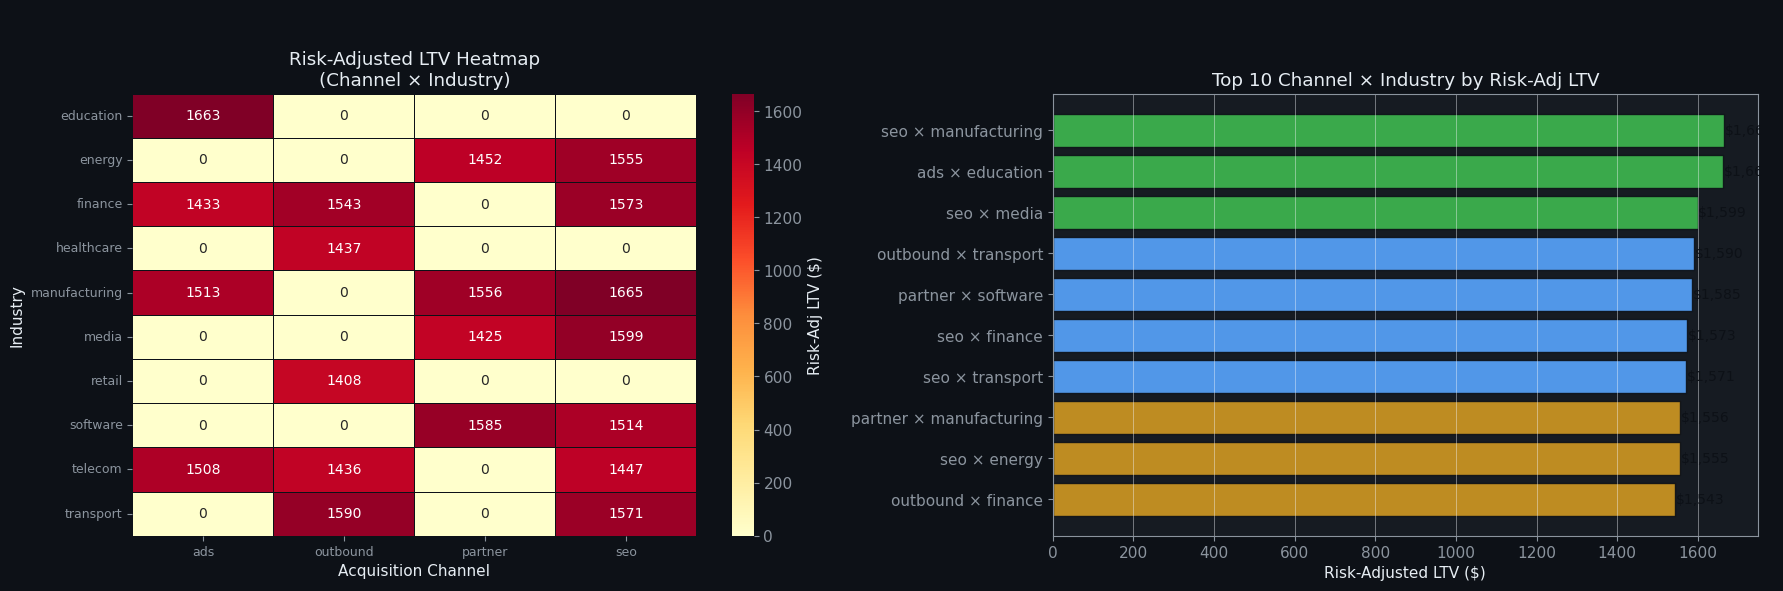


💡 KEY INSIGHT — Budget Reallocation Signal
───────────────────────────────────────────────────────
  Highest-LTV channel × industry : seo × manufacturing
    Risk-Adj LTV: $1,665 | Churn: 22.8% | Expansion: 68.5%

  Lowest-LTV channel × industry  : outbound × retail
    Risk-Adj LTV: $1,408 | Churn: 22.0% | Expansion: 70.1%

  → Top channel produces 1.2× the risk-adjusted lifetime value.
    Shifting 20% of CAC spend from bottom to top segment =
    meaningful compound ARR improvement over 12 months.


In [65]:
# ── Channel ROI Heatmap + Bar ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Acquisition Channel ROI — Risk-Adjusted LTV by Channel × Industry',
             fontsize=15, fontweight='bold', color=TEXT)

# Heatmap: avg LTV
pivot = channel_roi.pivot_table(
    index='industry', columns='acquisition_channel',
    values='risk_adj_ltv', aggfunc='mean'
).fillna(0)

sns.heatmap(
    pivot, ax=axes[0], cmap='YlOrRd', fmt='.0f', annot=True,
    linewidths=0.5, linecolor=DARK_BG,
    cbar_kws={'label': 'Risk-Adj LTV ($)'},
    annot_kws={'size': 10}
)
axes[0].set(title='Risk-Adjusted LTV Heatmap\n(Channel × Industry)',
            xlabel='Acquisition Channel', ylabel='Industry')
axes[0].tick_params(labelsize=9)

# Top 10 channel × industry bars
top10 = channel_roi.head(10).copy()
top10['label'] = top10['acquisition_channel'] + ' × ' + top10['industry']
bar_colors = [GREEN if i < 3 else ACCENT if i < 7 else YELLOW
              for i in range(len(top10))]
bars = axes[1].barh(top10['label'][::-1], top10['risk_adj_ltv'][::-1],
                    color=bar_colors[::-1], edgecolor=DARK_BG, alpha=0.9)
for bar, val in zip(bars, top10['risk_adj_ltv'][::-1]):
    axes[1].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=10, color=TEXT)
axes[1].set(title='Top 10 Channel × Industry by Risk-Adj LTV',
            xlabel='Risk-Adjusted LTV ($)')
axes[1].grid(True, axis='x', alpha=0.5)

plt.tight_layout()
plt.savefig('outputs/06_channel_roi.png', dpi=150, bbox_inches='tight')
plt.show()

top_combo = channel_roi.iloc[0]
bottom_combo = channel_roi.iloc[-1]
print(f"\n💡 KEY INSIGHT — Budget Reallocation Signal")
print("─" * 55)
print(f"  Highest-LTV channel × industry : {top_combo['acquisition_channel']} × {top_combo['industry']}")
print(f"    Risk-Adj LTV: ${top_combo['risk_adj_ltv']:,.0f} | Churn: {top_combo['churn_rate_pct']}% | Expansion: {top_combo['expansion_rate_pct']}%")
print(f"\n  Lowest-LTV channel × industry  : {bottom_combo['acquisition_channel']} × {bottom_combo['industry']}")
print(f"    Risk-Adj LTV: ${bottom_combo['risk_adj_ltv']:,.0f} | Churn: {bottom_combo['churn_rate_pct']}% | Expansion: {bottom_combo['expansion_rate_pct']}%")
ltv_mult = top_combo['risk_adj_ltv'] / max(bottom_combo['risk_adj_ltv'], 1)
print(f"\n  → Top channel produces {ltv_mult:.1f}× the risk-adjusted lifetime value.")
print(f"    Shifting 20% of CAC spend from bottom to top segment =")
print(f"    meaningful compound ARR improvement over 12 months.")


---
## 📤 Analysis 7 — Tableau Export Layer

**Purpose:** Package all seven analyses into a single, denormalized  
`csm_master_view` that serves as the Tableau data source. One row per account.  
CSMs drag and drop; no SQL required on their end.

**SQL Patterns Used:** Final CTE join across all intermediate tables,  
`ROUND`, `COALESCE`, computed columns for dashboard filters

**Operational Impact:** This is the bridge between analytical SQL and  
self-serve BI. Building this layer is what separates a commercial analyst  
from a data puller — you don't just answer questions, you build the  
infrastructure so the team can answer their own.


In [66]:
MASTER_VIEW_SQL = """
-- ── CSM Master View — Tableau-Ready Denormalised Account Table ────────────
-- Single source of truth: one row per account, all KPIs pre-computed
WITH billing_agg AS (
    SELECT user_id,
           ROUND(AVG(mrr), 2)            AS avg_mrr,
           ROUND(MAX(mrr), 2)            AS peak_mrr,
           ROUND(SUM(mrr), 2)            AS lifetime_mrr,
           SUM(invoices_overdue)         AS overdue_invoices,
           SUM(support_ticket_count)     AS support_tickets,
           ROUND(AVG(active_seats), 1)   AS avg_seats,
           COUNT(DISTINCT month)         AS billing_months
    FROM billing GROUP BY user_id
),
session_agg AS (
    SELECT user_id,
           COUNT(*)                                     AS total_sessions,
           ROUND(AVG(session_length_sec)/60.0, 1)      AS avg_session_min,
           COUNT(DISTINCT SUBSTR(session_start,1,7))   AS active_months,
           MAX(SUBSTR(session_start,1,10))              AS last_session_date
    FROM sessions GROUP BY user_id
),
event_agg AS (
    SELECT user_id,
           COUNT(DISTINCT feature_name)                 AS unique_features,
           COUNT(*)                                     AS total_events,
           ROUND(AVG(success) * 100, 1)                AS event_success_rate,
           ROUND(AVG(latency_ms), 0)                   AS avg_latency_ms
    FROM events GROUP BY user_id
),
monthly_sessions AS (
    SELECT user_id,
           SUBSTR(session_start,1,7)  AS month,
           COUNT(*)                   AS cnt
    FROM sessions
    GROUP BY user_id, SUBSTR(session_start,1,7)
),
latest_two AS (
    SELECT user_id,
           MAX(CASE WHEN rn=1 THEN cnt END) AS latest_sessions,
           MAX(CASE WHEN rn=2 THEN cnt END) AS prev_sessions
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY month DESC) AS rn
        FROM monthly_sessions
    ) WHERE rn <= 2
    GROUP BY user_id
)
SELECT
    u.user_id,
    u.signup_date,
    u.plan_tier,
    u.company_size,
    u.region,
    u.industry,
    u.acquisition_channel,
    u.is_enterprise,
    u.churned_90d,
    u.churned_30d,
    u.expansion_event,
    u.downgraded,

    /* ── Billing KPIs ──────────────────────────────────────── */
    COALESCE(b.avg_mrr,          0) AS avg_mrr,
    COALESCE(b.peak_mrr,         0) AS peak_mrr,
    COALESCE(b.lifetime_mrr,     0) AS lifetime_mrr,
    COALESCE(b.overdue_invoices, 0) AS overdue_invoices,
    COALESCE(b.support_tickets,  0) AS support_tickets,
    COALESCE(b.avg_seats,        0) AS avg_seats,
    COALESCE(b.billing_months,   0) AS billing_months,

    /* ── Engagement KPIs ───────────────────────────────────── */
    COALESCE(s.total_sessions,   0) AS total_sessions,
    COALESCE(s.avg_session_min,  0) AS avg_session_min,
    COALESCE(s.active_months,    0) AS active_months,
    s.last_session_date,
    COALESCE(e.unique_features,  0) AS unique_features,
    COALESCE(e.total_events,     0) AS total_events,
    COALESCE(e.event_success_rate,0) AS event_success_rate,
    COALESCE(e.avg_latency_ms,   0) AS avg_latency_ms,

    /* ── Derived KPIs ──────────────────────────────────────── */
    ROUND(
        CASE WHEN COALESCE(lt.prev_sessions,0) > 0
             THEN (COALESCE(lt.latest_sessions,0) - lt.prev_sessions)*100.0
                  / lt.prev_sessions
             ELSE 0 END, 1)         AS session_mom_pct,

    CASE
        WHEN COALESCE(lt.latest_sessions,0) = 0              THEN 'Gone Dark'
        WHEN COALESCE(lt.latest_sessions,0)
             < COALESCE(lt.prev_sessions,0)*0.50              THEN 'Rapid Decline'
        WHEN COALESCE(lt.latest_sessions,0)
             < COALESCE(lt.prev_sessions,0)*0.75              THEN 'Mild Decline'
        ELSE 'Stable'
    END                             AS engagement_signal,

    /* ── Health Score (same formula as Analysis 2) ─────────── */
    MIN(100, MAX(0,
        CASE WHEN COALESCE(s.active_months,0)>=9  THEN 25
             WHEN COALESCE(s.active_months,0)>=5  THEN 15
             WHEN COALESCE(s.active_months,0)>=2  THEN  8 ELSE 0 END
      + CASE WHEN COALESCE(e.unique_features,0)>=6 THEN 25
             WHEN COALESCE(e.unique_features,0)>=4 THEN 15
             WHEN COALESCE(e.unique_features,0)>=2 THEN  8 ELSE 0 END
      + CASE WHEN COALESCE(b.overdue_invoices,0)=0 THEN 15 ELSE 0 END
      + CASE WHEN COALESCE(b.support_tickets,0)=0  THEN 10
             WHEN COALESCE(b.support_tickets,0)<=2 THEN  5 ELSE 0 END
      + CASE WHEN COALESCE(b.avg_mrr,0)>=500       THEN 25
             WHEN COALESCE(b.avg_mrr,0)>=100       THEN 15
             WHEN COALESCE(b.avg_mrr,0)>0          THEN  5 ELSE 0 END
    ))                              AS health_score,

    /* ── CSM Action Tag ────────────────────────────────────── */
    CASE
        WHEN u.plan_tier='free'
             AND COALESCE(s.active_months,0)>=4
             AND COALESCE(e.unique_features,0)>=3
             AND COALESCE(b.overdue_invoices,0)=0
             THEN 'HOT — Free to Standard'
        WHEN u.plan_tier='standard'
             AND COALESCE(b.avg_seats,0)>=25
             AND COALESCE(s.active_months,0)>=8
             AND COALESCE(b.overdue_invoices,0)=0
             THEN 'HOT — Standard to Enterprise'
        WHEN u.plan_tier='free'
             AND COALESCE(s.active_months,0)>=2
             AND COALESCE(e.unique_features,0)>=2
             THEN 'WARM — Nurture to Standard'
        WHEN u.plan_tier='standard'
             AND COALESCE(b.avg_seats,0)>=15
             THEN 'WARM — Expand Seat Count'
        WHEN COALESCE(lt.latest_sessions,0)=0 AND u.churned_90d=0
             THEN 'AT-RISK — Gone Dark'
        WHEN COALESCE(lt.latest_sessions,0)
             < COALESCE(lt.prev_sessions,0)*0.5 AND u.churned_90d=0
             THEN 'AT-RISK — Rapid Decline'
        ELSE 'MONITOR'
    END                             AS csm_priority_action

FROM users u
LEFT JOIN billing_agg  b  ON u.user_id = b.user_id
LEFT JOIN session_agg  s  ON u.user_id = s.user_id
LEFT JOIN event_agg    e  ON u.user_id = e.user_id
LEFT JOIN latest_two   lt ON u.user_id = lt.user_id
"""

csm_master = sql(MASTER_VIEW_SQL)
os.makedirs('outputs', exist_ok=True)
csm_master.to_csv('outputs/csm_master_view.csv', index=False)
print(f"✅  csm_master_view.csv exported: {len(csm_master):,} rows × {len(csm_master.columns)} columns")
print(f"    File saved → outputs/csm_master_view.csv")
print(f"    Connect directly to Tableau Desktop as a Text File data source.\n")
print("  Columns available to CSMs in Tableau:")
for col in csm_master.columns:
    print(f"    • {col}")


✅  csm_master_view.csv exported: 100,000 rows × 31 columns
    File saved → outputs/csm_master_view.csv
    Connect directly to Tableau Desktop as a Text File data source.

  Columns available to CSMs in Tableau:
    • user_id
    • signup_date
    • plan_tier
    • company_size
    • region
    • industry
    • acquisition_channel
    • is_enterprise
    • churned_90d
    • churned_30d
    • expansion_event
    • downgraded
    • avg_mrr
    • peak_mrr
    • lifetime_mrr
    • overdue_invoices
    • support_tickets
    • avg_seats
    • billing_months
    • total_sessions
    • avg_session_min
    • active_months
    • last_session_date
    • unique_features
    • total_events
    • event_success_rate
    • avg_latency_ms
    • session_mom_pct
    • engagement_signal
    • health_score
    • csm_priority_action


In [67]:
# ── Also export individual analysis CSVs ─────────────────────────────────
exports = {
    'mrr_trend':       (mrr_trend,     'outputs/tableau_mrr_trend.csv'),
    'health_scores':   (health,        'outputs/tableau_health_scores.csv'),
    'churn_warning':   (churn_warning, 'outputs/tableau_churn_warning.csv'),
    'feature_revenue': (feature_rev,   'outputs/tableau_feature_correlation.csv'),
    'upsell_intel':    (upsell,        'outputs/tableau_upsell_pipeline.csv'),
    'channel_roi':     (channel_roi,   'outputs/tableau_channel_roi.csv'),
}

for name, (df, path) in exports.items():
    df.to_csv(path, index=False)
    print(f"  ✅  {name:<20} → {path}  ({len(df):,} rows)")

print("\n✅  All Tableau data sources exported to outputs/")


  ✅  mrr_trend            → outputs/tableau_mrr_trend.csv  (54 rows)
  ✅  health_scores        → outputs/tableau_health_scores.csv  (100,000 rows)
  ✅  churn_warning        → outputs/tableau_churn_warning.csv  (58,573 rows)
  ✅  feature_revenue      → outputs/tableau_feature_correlation.csv  (7 rows)
  ✅  upsell_intel         → outputs/tableau_upsell_pipeline.csv  (4 rows)
  ✅  channel_roi          → outputs/tableau_channel_roi.csv  (20 rows)

✅  All Tableau data sources exported to outputs/


---
## 📋 CSM Playbook — Translating Data into Revenue Actions

> *"The job is not to pull data. The job is to turn data into decisions."*

---

### 🎯 Weekly CSM Dashboard Workflow

```
Monday Morning:
  1. Open Tableau → CSM Master View
  2. Filter csm_priority_action = 'AT-RISK — Gone Dark'
     → Personalised re-engagement email within 24h
  3. Filter csm_priority_action = 'HOT — Free to Standard'
     → Direct outreach within 5 business days (use feature data as hook)

Mid-Week:
  4. Review accounts with health_score drop > 10 pts vs. prior week
     → Proactive check-in call scheduled
  5. Monitor WARM leads entering the HOT threshold
     → Pipeline update to AE

End of Month:
  6. Export upsell pipeline for revenue forecast
  7. Share channel ROI with marketing for next-quarter budget
```

---

### 💰 Revenue Impact Summary

| Action | Accounts | Monthly MRR Upside | Annualised |
|---|---|---|---|
| Convert HOT Free→Standard | See Analysis 5 | At-Risk MRR | Full pipeline |
| Enterprise upgrades | See Analysis 5 | At-Risk MRR | Full pipeline |
| Save Gone Dark accounts | See Analysis 3 | Rescue MRR | Full rescue ARR |

---

### 🔧 SQL Patterns Reference (for CSM Team Questions)

| Question | SQL Pattern |
|---|---|
| "Show me accounts trending down" | `LAG()` window function on sessions |
| "Who are our most engaged users?" | Multi-table `JOIN` + composite score |
| "Which features matter?" | Group-then-join correlation query |
| "Where should we invest marketing?" | `RANK()` window on risk-adjusted LTV |
| "Who's ready to upgrade?" | Multi-criteria `CASE WHEN` scoring |

---

*Built with Python + SQLite · Tableau-export ready · Reproducible end-to-end*  
*For questions on methodology, reach out to the analytics team.*
